# 16 - Live Package Mode Smoke Test

This notebook is now the live package-mode runbook.

It does three things:

1. Builds a small `SurveyedNation` from real survey rows
2. Runs a small live package-mode simulation with real API calls
3. Saves and inspects the resulting CSV and PNG artifacts

In [12]:
import importlib
import os, sys, random, logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR
OUTPUT_DIR = REPO_ROOT / 'data' / 'output' / 'experiments'

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')
logging.getLogger('httpx').setLevel(logging.WARNING)
logging.getLogger('httpcore').setLevel(logging.WARNING)

import cag.abm.sim as sim_module
importlib.reload(sim_module)

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import (
    ALL_CLIMATE_POLICIES,
    PRO_CLIMATE_INDEX_COLUMN,
 )
from cag.abm.sim import (
    run_simulation,
    collect_ground_truth,
    collect_package_ground_truth,
    save_results,
    save_result_plots,
 )

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
 )

print('Imports OK')
print(f'Repo root: {REPO_ROOT}')
print(f'Output dir: {OUTPUT_DIR}')

Imports OK
Repo root: /Users/vbwt265/src/GitHub/Climate-Action-GABM
Output dir: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments


## 1. Build a Live Sample Nation

This helper builds a small `SurveyedNation` from real survey rows so the live run stays cheap and fast.

In [2]:
N_CITIZENS = 5
YEAR = 2026
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

def build_sample_nation(n_citizens=N_CITIZENS, sample_seed=RANDOM_SEED):
    nation = SurveyedNation(
        year=YEAR, place='UK',
        gender_map=GenderMap(),
        region_map=UKRegionMap(),
        education_map=SurveyEducationMap(),
        ethnicity_map=SurveyEthnicityMap(),
        income_map=SurveyIncomeMap(),
        politics_map=SurveyPoliticsMap(),
        family_map=SurveyFamilyMap(),
        ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
        brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
        selftransc_map=SelftranscMap,
        selfenh_map=SelfenhMap,
        openness_map=OpennessMap,
        conformtrad_map=ConformTradMap,
        sdo_map=SDOMap,
        edo_map=EDOMap,
        rwa_map=RWAMap,
    )

    data = load('../data/yougov_survey_data/YouGovProcessedData.csv')
    data = data.sample(n=n_citizens, random_state=sample_seed).reset_index(drop=True)

    for i in range(len(data)):
        row = data.iloc[i]
        citizen = SurveyedCitizen(
            agent_id=row.get('ID', None), environment=nation,
            year_of_birth=YEAR - int(row.get('age', 0)),
            gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
            region_id=RegionID(int(row.get('tprofile_GOR', 0))),
            education_id=EducationID(int(row.get('profile_education_level', 0))),
            income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
            ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
            family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
            ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
            brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
            politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
            selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
            selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
            openness_id=rescale_1_6(int(row.get('Openness', 0))),
            conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
            sdo_id=rescale_1_7(int(row.get('SDO', 0))),
            edo_id=rescale_1_7(int(row.get('EDO', 0))),
            rwa_id=rescale_1_6(int(row.get('RWA', 0))),
            original_survey_data=data.iloc[i],
        )
        nation.agents_active[citizen.id] = citizen

    return nation, data

sample_nation, sample_data = build_sample_nation()
print(f'Default sample nation ready: {len(sample_nation.agents_active)} agents')
sample_data[['ID']].head()

INFO Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
INFO Column with most NaNs: tprofile_gross_household (398 NaNs)
INFO 1483 rows after filtering.


Default sample nation ready: 5 agents


,ID
0,165
1,582
2,1379
3,713
4,1878


## 2. Live API Run

This section runs the package mode with real API calls on a very small sample: **5 agents, 2 days**.

It is intended as a minimal live smoke test rather than a substantive experiment.

Requirements:
- valid API keys configured through the repo's existing key-loading path
- acceptance that this section will make paid API calls when executed

The default configuration below uses `gpt-4o-mini` for both messaging and surveys to keep costs down.

In [3]:
LIVE_N_CITIZENS = 5
LIVE_N_DAYS = 2
LIVE_SAMPLE_SEED = RANDOM_SEED + 7

live_sn, live_sampled_data = build_sample_nation(
    n_citizens=LIVE_N_CITIZENS,
    sample_seed=LIVE_SAMPLE_SEED,
 )

live_config = {
    'communication_mode': 'package',
    'package_policies': list(ALL_CLIMATE_POLICIES),
    'days': [
        {'phases': ['P-A', 'P-B', 'C']},
    ] * LIVE_N_DAYS,
    'k_peers_per_day': 2,
    'llm_model': 'gpt-4o-mini',
    'llm_provider': 'openai',
    'llm_temperature': 0.5,
    'survey_model': 'gpt-4o-mini',
    'survey_provider': 'openai',
    'thinking': False,
    'debias': True,
    'p_intra': 0.15,
    'p_inter': 0.02,
    'random_seed': RANDOM_SEED,
}

print(f"Live smoke test config: {LIVE_N_CITIZENS} agents, {LIVE_N_DAYS} days")
print(f"Main model: {live_config['llm_model']} ({live_config['llm_provider']})")
print(f"Survey model: {live_config['survey_model']} ({live_config['survey_provider']})")
print(f"Debiasing: {live_config['debias']}")

INFO Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
INFO Column with most NaNs: tprofile_gross_household (398 NaNs)
INFO 1483 rows after filtering.


Live smoke test config: 5 agents, 2 days
Main model: gpt-4o-mini (openai)
Survey model: gpt-4o-mini (openai)
Debiasing: True


In [4]:
live_results = run_simulation(live_config, live_sn)

live_df_traj = live_results['opinion_trajectories']
live_df_package = live_results['package_index_trajectories']
live_df_ref = live_results['reflections']
live_gt_policy_df = collect_ground_truth(live_sn.agents_active.values())
live_gt_package_df = collect_package_ground_truth(live_sn.agents_active.values())

expected_live_policy_rows = LIVE_N_CITIZENS * len(ALL_CLIMATE_POLICIES) * (LIVE_N_DAYS + 1)
expected_live_package_rows = LIVE_N_CITIZENS * (LIVE_N_DAYS + 1)

assert len(live_df_traj) == expected_live_policy_rows, (
    f'Expected {expected_live_policy_rows} live policy rows, got {len(live_df_traj)}'
 )
assert len(live_df_package) == expected_live_package_rows, (
    f'Expected {expected_live_package_rows} live package rows, got {len(live_df_package)}'
 )
assert set(live_df_package['index_name'].unique()) == {PRO_CLIMATE_INDEX_COLUMN}

live_recomputed_package = (
    live_df_traj.groupby(['agent_id', 'day'])['numeric']
    .mean()
    .reset_index(name='recomputed_package_index')
)
live_merged_package = live_df_package.merge(
    live_recomputed_package, on=['agent_id', 'day']
 )
assert np.allclose(
    live_merged_package['package_index'],
    live_merged_package['recomputed_package_index'],
), 'Live package index should equal the mean of the six live policy scores on the centered scale'

print(f"Live policy trajectory rows: {len(live_df_traj)}")
print(f"Live package index rows: {len(live_df_package)}")
print(f"Live reflection rows: {len(live_df_ref)}")
print(f"Live GT package mean: {live_gt_package_df['ground_truth'].mean():+.3f}")
live_df_package.head()

INFO Simulation: 5 agents, 2 days
INFO Running package baseline survey (day 0), policies=['ClimatePolicyID(1)', 'ClimatePolicyID(2)', 'ClimatePolicyID(3)', 'ClimatePolicyID(4)', 'ClimatePolicyID(5)', 'ClimatePolicyID(6)']
INFO Day 0 mean package index: +0.93
INFO --- Day 1/2 (package=climate_policy_package, phases=['P-A', 'P-B', 'C']) ---
INFO [P-A] Day 1: delivered package message to 5 citizens. Message (first 120 chars): In the face of the climate crisis, we have a profound opportunity to reshape our future for the better. I wholeheartedly...
INFO [P-A] Sample package reflection: Reflecting on the proposed climate policies, I find myself strongly supportive of several aspects. Accelerating the roll-out of renewable energy production resonates with my belief in equal access to ...
INFO [P-B] Day 1: delivered package message to 4 citizens. Message (first 120 chars): Let’s be clear: the government’s climate policies are a full-frontal assault on ordinary British people, all under the g.

Live policy trajectory rows: 90
Live package index rows: 15
Live reflection rows: 22
Live GT package mean: +0.400


,agent_id,day,index_name,package_scope,package_index
0,1066.0,0,ProClimatePolSupp,climate_policy_package,2.166667
1,1066.0,1,ProClimatePolSupp,climate_policy_package,2.333333
2,1066.0,2,ProClimatePolSupp,climate_policy_package,2.333333
3,1260.0,0,ProClimatePolSupp,climate_policy_package,1.833333
4,1260.0,1,ProClimatePolSupp,climate_policy_package,1.500000


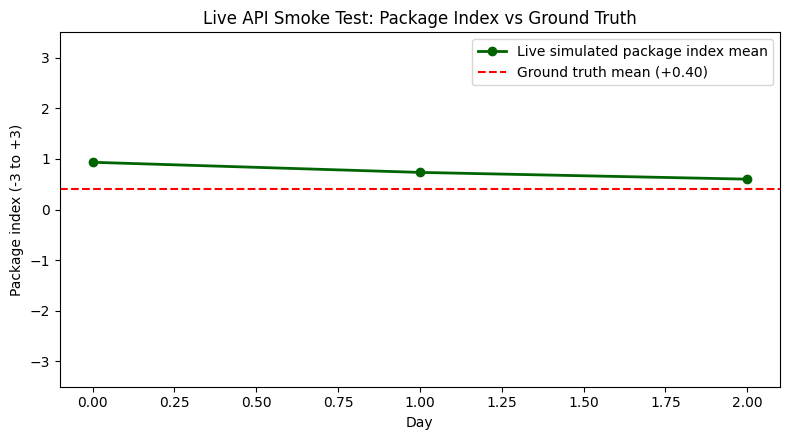

Live sample agent: 1066.0


policy_id,ClimatePolicyID(1),ClimatePolicyID(2),ClimatePolicyID(3),ClimatePolicyID(4),ClimatePolicyID(5),ClimatePolicyID(6)
day,,,,,,
0,3,2,2,2,2,2
1,3,2,2,2,3,2
2,3,3,2,2,2,2


In [5]:
live_mean_package = live_df_package.groupby('day')['package_index'].mean()
live_gt_mean = live_gt_package_df['ground_truth'].mean()

plt.figure(figsize=(8, 4.5))
plt.plot(
    live_mean_package.index,
    live_mean_package.values,
    marker='o',
    color='darkgreen',
    linewidth=2,
    label='Live simulated package index mean',
)
plt.axhline(
    live_gt_mean,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Ground truth mean ({live_gt_mean:+.2f})',
)
plt.ylim(-3.5, 3.5)
plt.xlabel('Day')
plt.ylabel('Package index (-3 to +3)')
plt.title('Live API Smoke Test: Package Index vs Ground Truth')
plt.legend()
plt.tight_layout()
plt.show()

live_sample_agent = live_df_traj['agent_id'].iloc[0]
live_sample_policy_view = (
    live_df_traj[live_df_traj['agent_id'] == live_sample_agent]
    .pivot(index='day', columns='policy_id', values='numeric')
    .sort_index()
)
print(f'Live sample agent: {live_sample_agent}')
live_sample_policy_view

## 3. Inspect Saved Outputs

This section saves the live run output directory, writes the standard PNG plot bundle, reads the saved CSV artifacts back from disk, and previews the PNGs inline.

Notes:

- `messages.csv` should populate for any live run
- `survey_reasoning.csv` only populates when `live_config['debias'] = True`
- `daily_summaries.csv` only populates once the run reaches day 3+, because memory compression starts on day 3
- package-mode runs should also write `package_index_trajectories.png` and `package_index_shares.png` in addition to the per-policy PNG outputs
- if you want all three artifact types populated in this notebook, set `LIVE_N_DAYS = 3` and `live_config['debias'] = True` before running the live cells

INFO Results saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938
INFO Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938/opinion_trajectories.png
INFO Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938/opinion_shares.png
INFO Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938/package_index_trajectories.png
INFO Plot saved to /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938/package_index_shares.png


Live outputs saved to: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260422_183938
messages.csv rows: 22
survey_reasoning.csv rows: 90
daily_summaries.csv rows: 0
PNG plots written:
  opinion_shares: opinion_shares.png
  opinion_trajectories: opinion_trajectories.png
  package_index_shares: package_index_shares.png
  package_index_trajectories: package_index_trajectories.png


{'csv_files': ['daily_summaries.csv',
  'ground_truth.csv',
  'messages.csv',
  'opinion_shares.csv',
  'opinion_trajectories.csv',
  'package_ground_truth.csv',
  'package_index_shares.csv',
  'package_index_trajectories.csv',
  'reflections.csv',
  'survey_reasoning.csv'],
 'png_files': ['opinion_shares.png',
  'opinion_trajectories.png',
  'package_index_shares.png',
  'package_index_trajectories.png']}

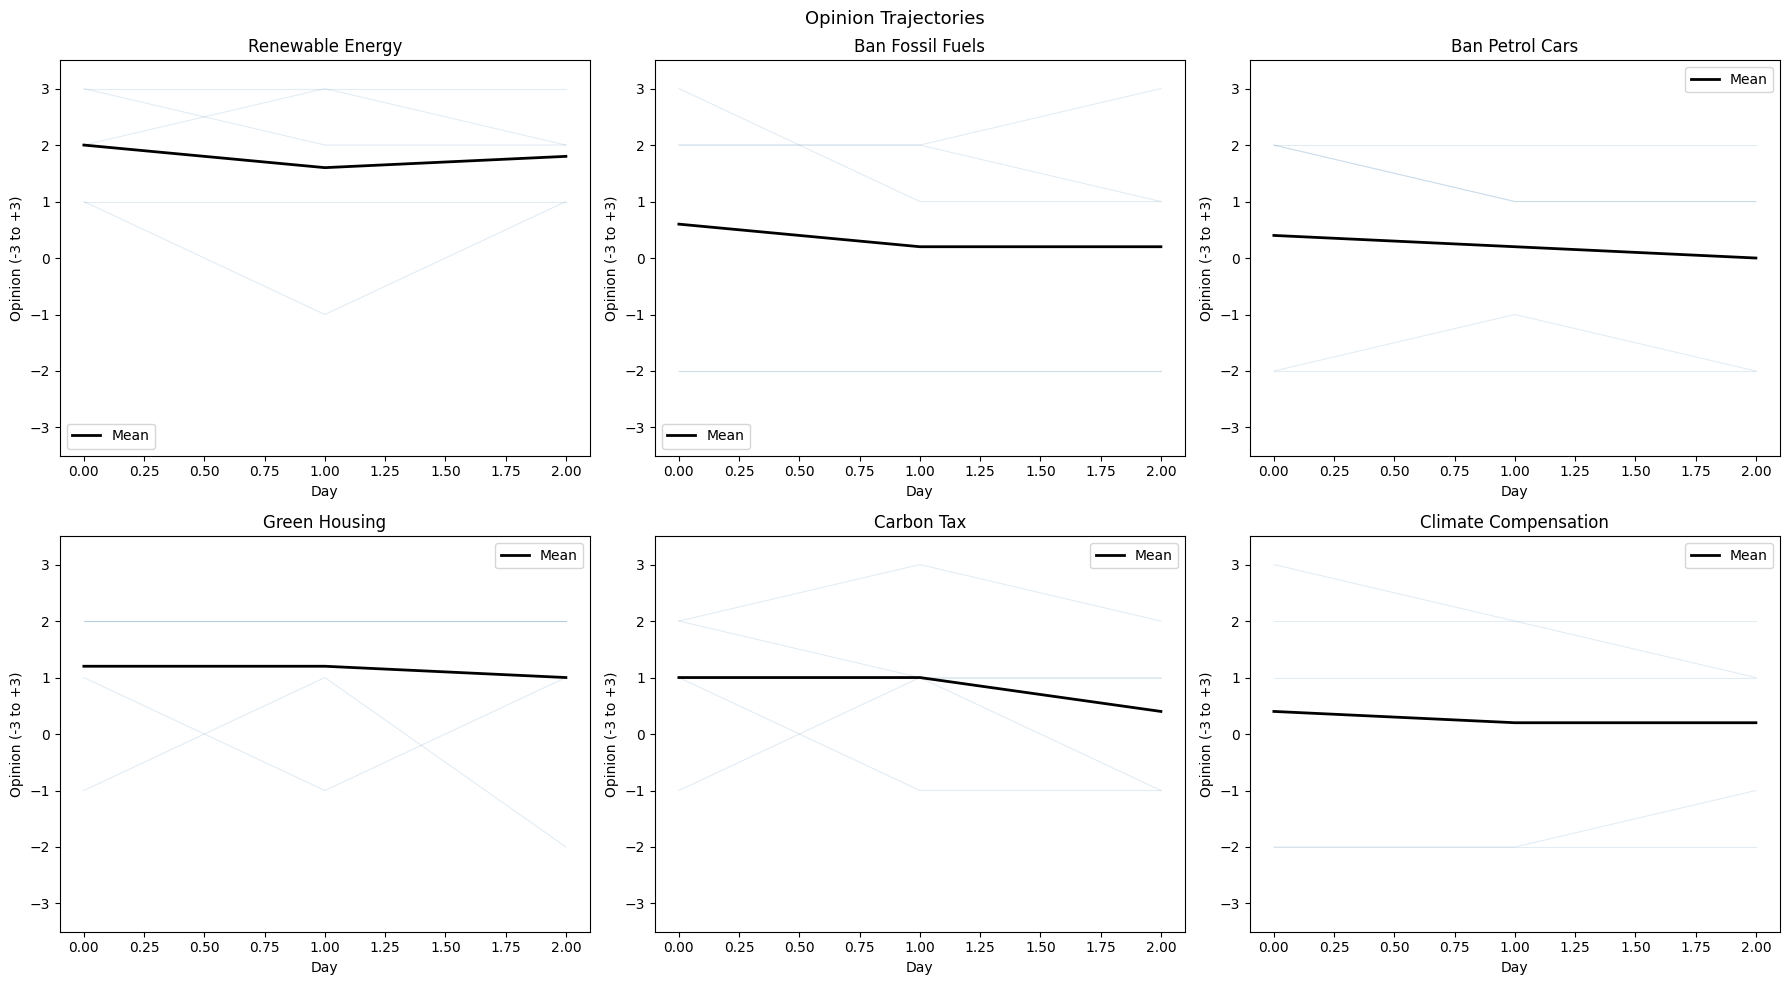

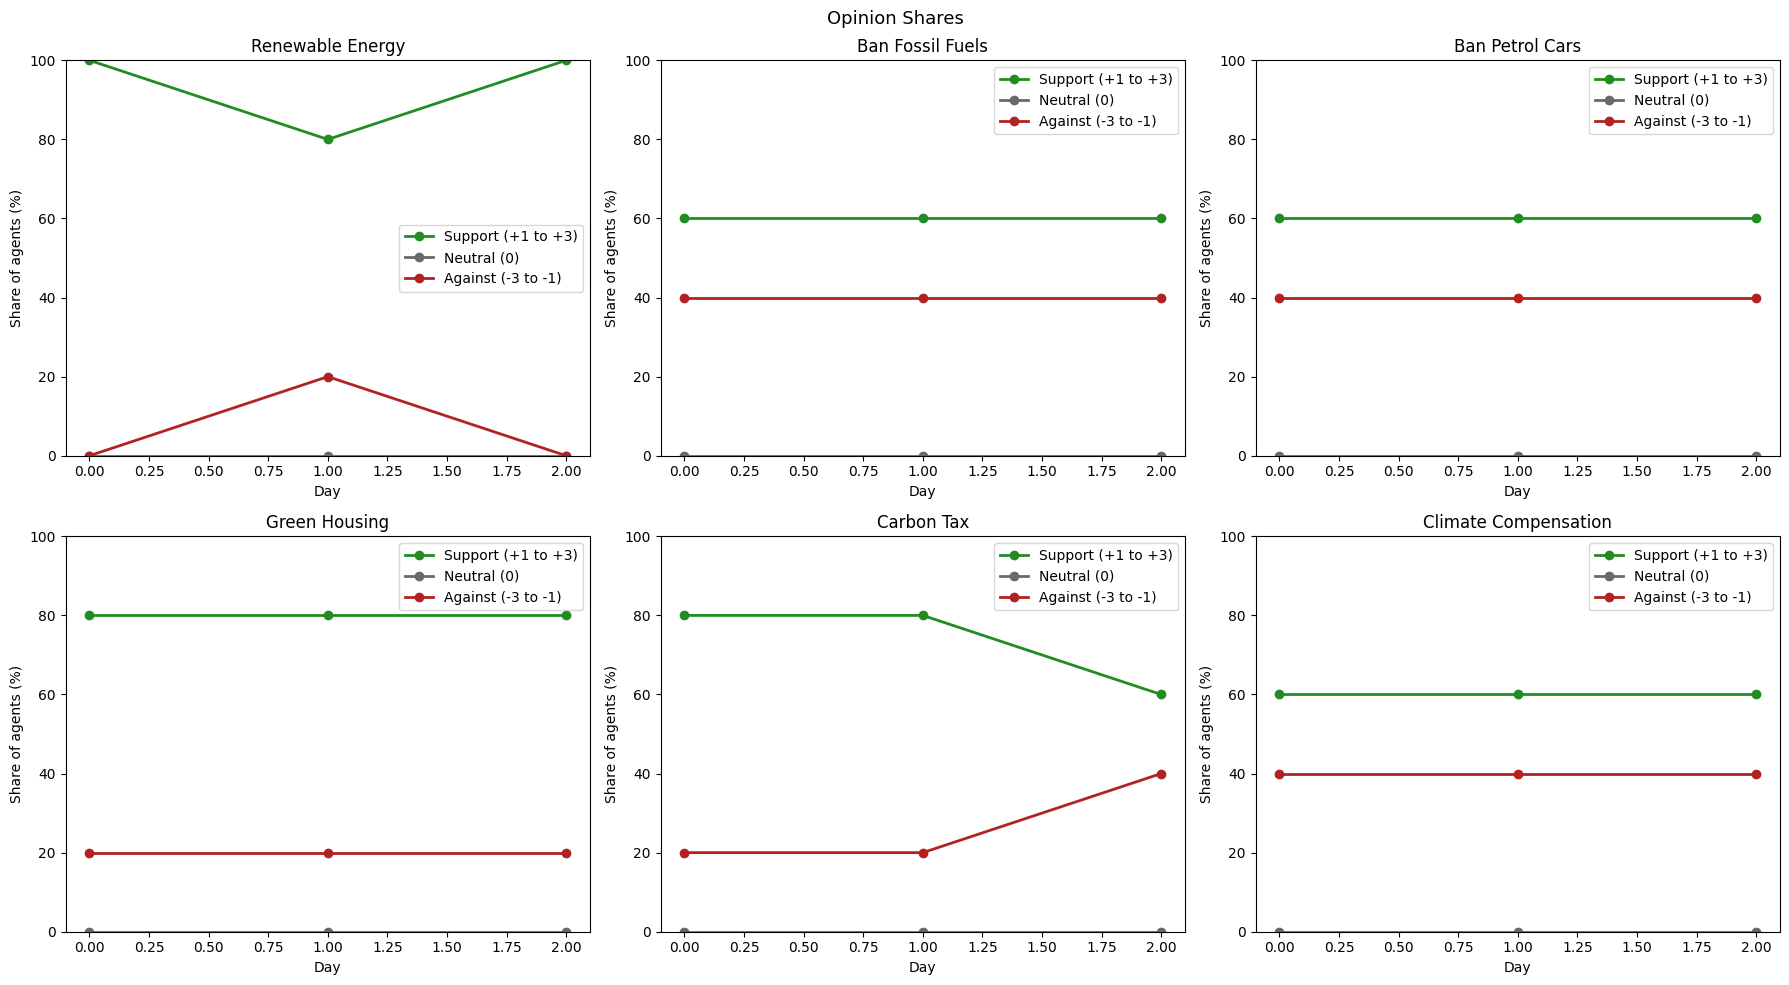

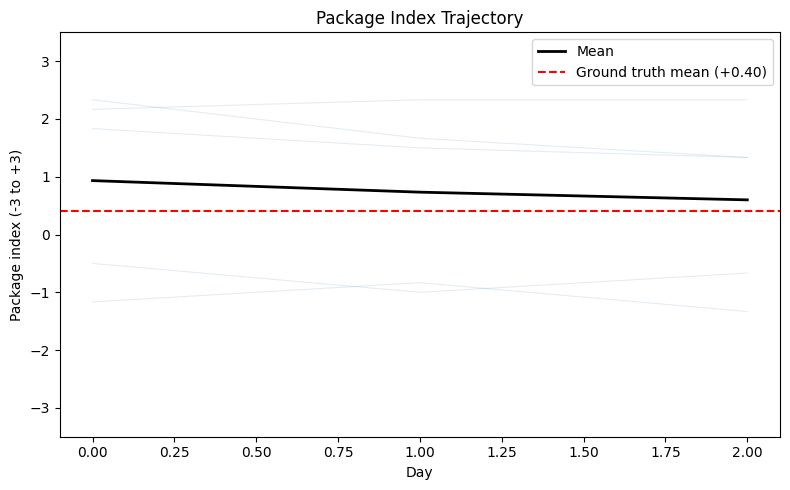

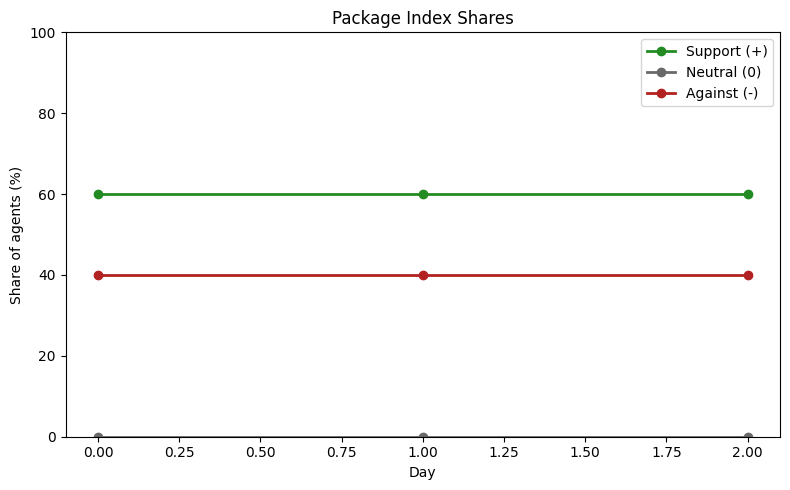

In [13]:
live_output_dir = save_results(live_results, output_dir=OUTPUT_DIR)
live_plot_paths = save_result_plots(live_results, live_output_dir)
live_messages_csv = pd.read_csv(live_output_dir / 'messages.csv')
live_reasoning_csv = pd.read_csv(live_output_dir / 'survey_reasoning.csv')
live_summaries_csv = pd.read_csv(live_output_dir / 'daily_summaries.csv')

print(f'Live outputs saved to: {live_output_dir}')
print(f'messages.csv rows: {len(live_messages_csv)}')
print(f'survey_reasoning.csv rows: {len(live_reasoning_csv)}')
print(f'daily_summaries.csv rows: {len(live_summaries_csv)}')
print('PNG plots written:')
for plot_name, plot_path in sorted(live_plot_paths.items()):
    print(f'  {plot_name}: {plot_path.name}')

{
    'csv_files': sorted(path.name for path in live_output_dir.glob('*.csv')),
    'png_files': sorted(path.name for path in live_output_dir.glob('*.png')),
}

Inline preview: opinion_shares


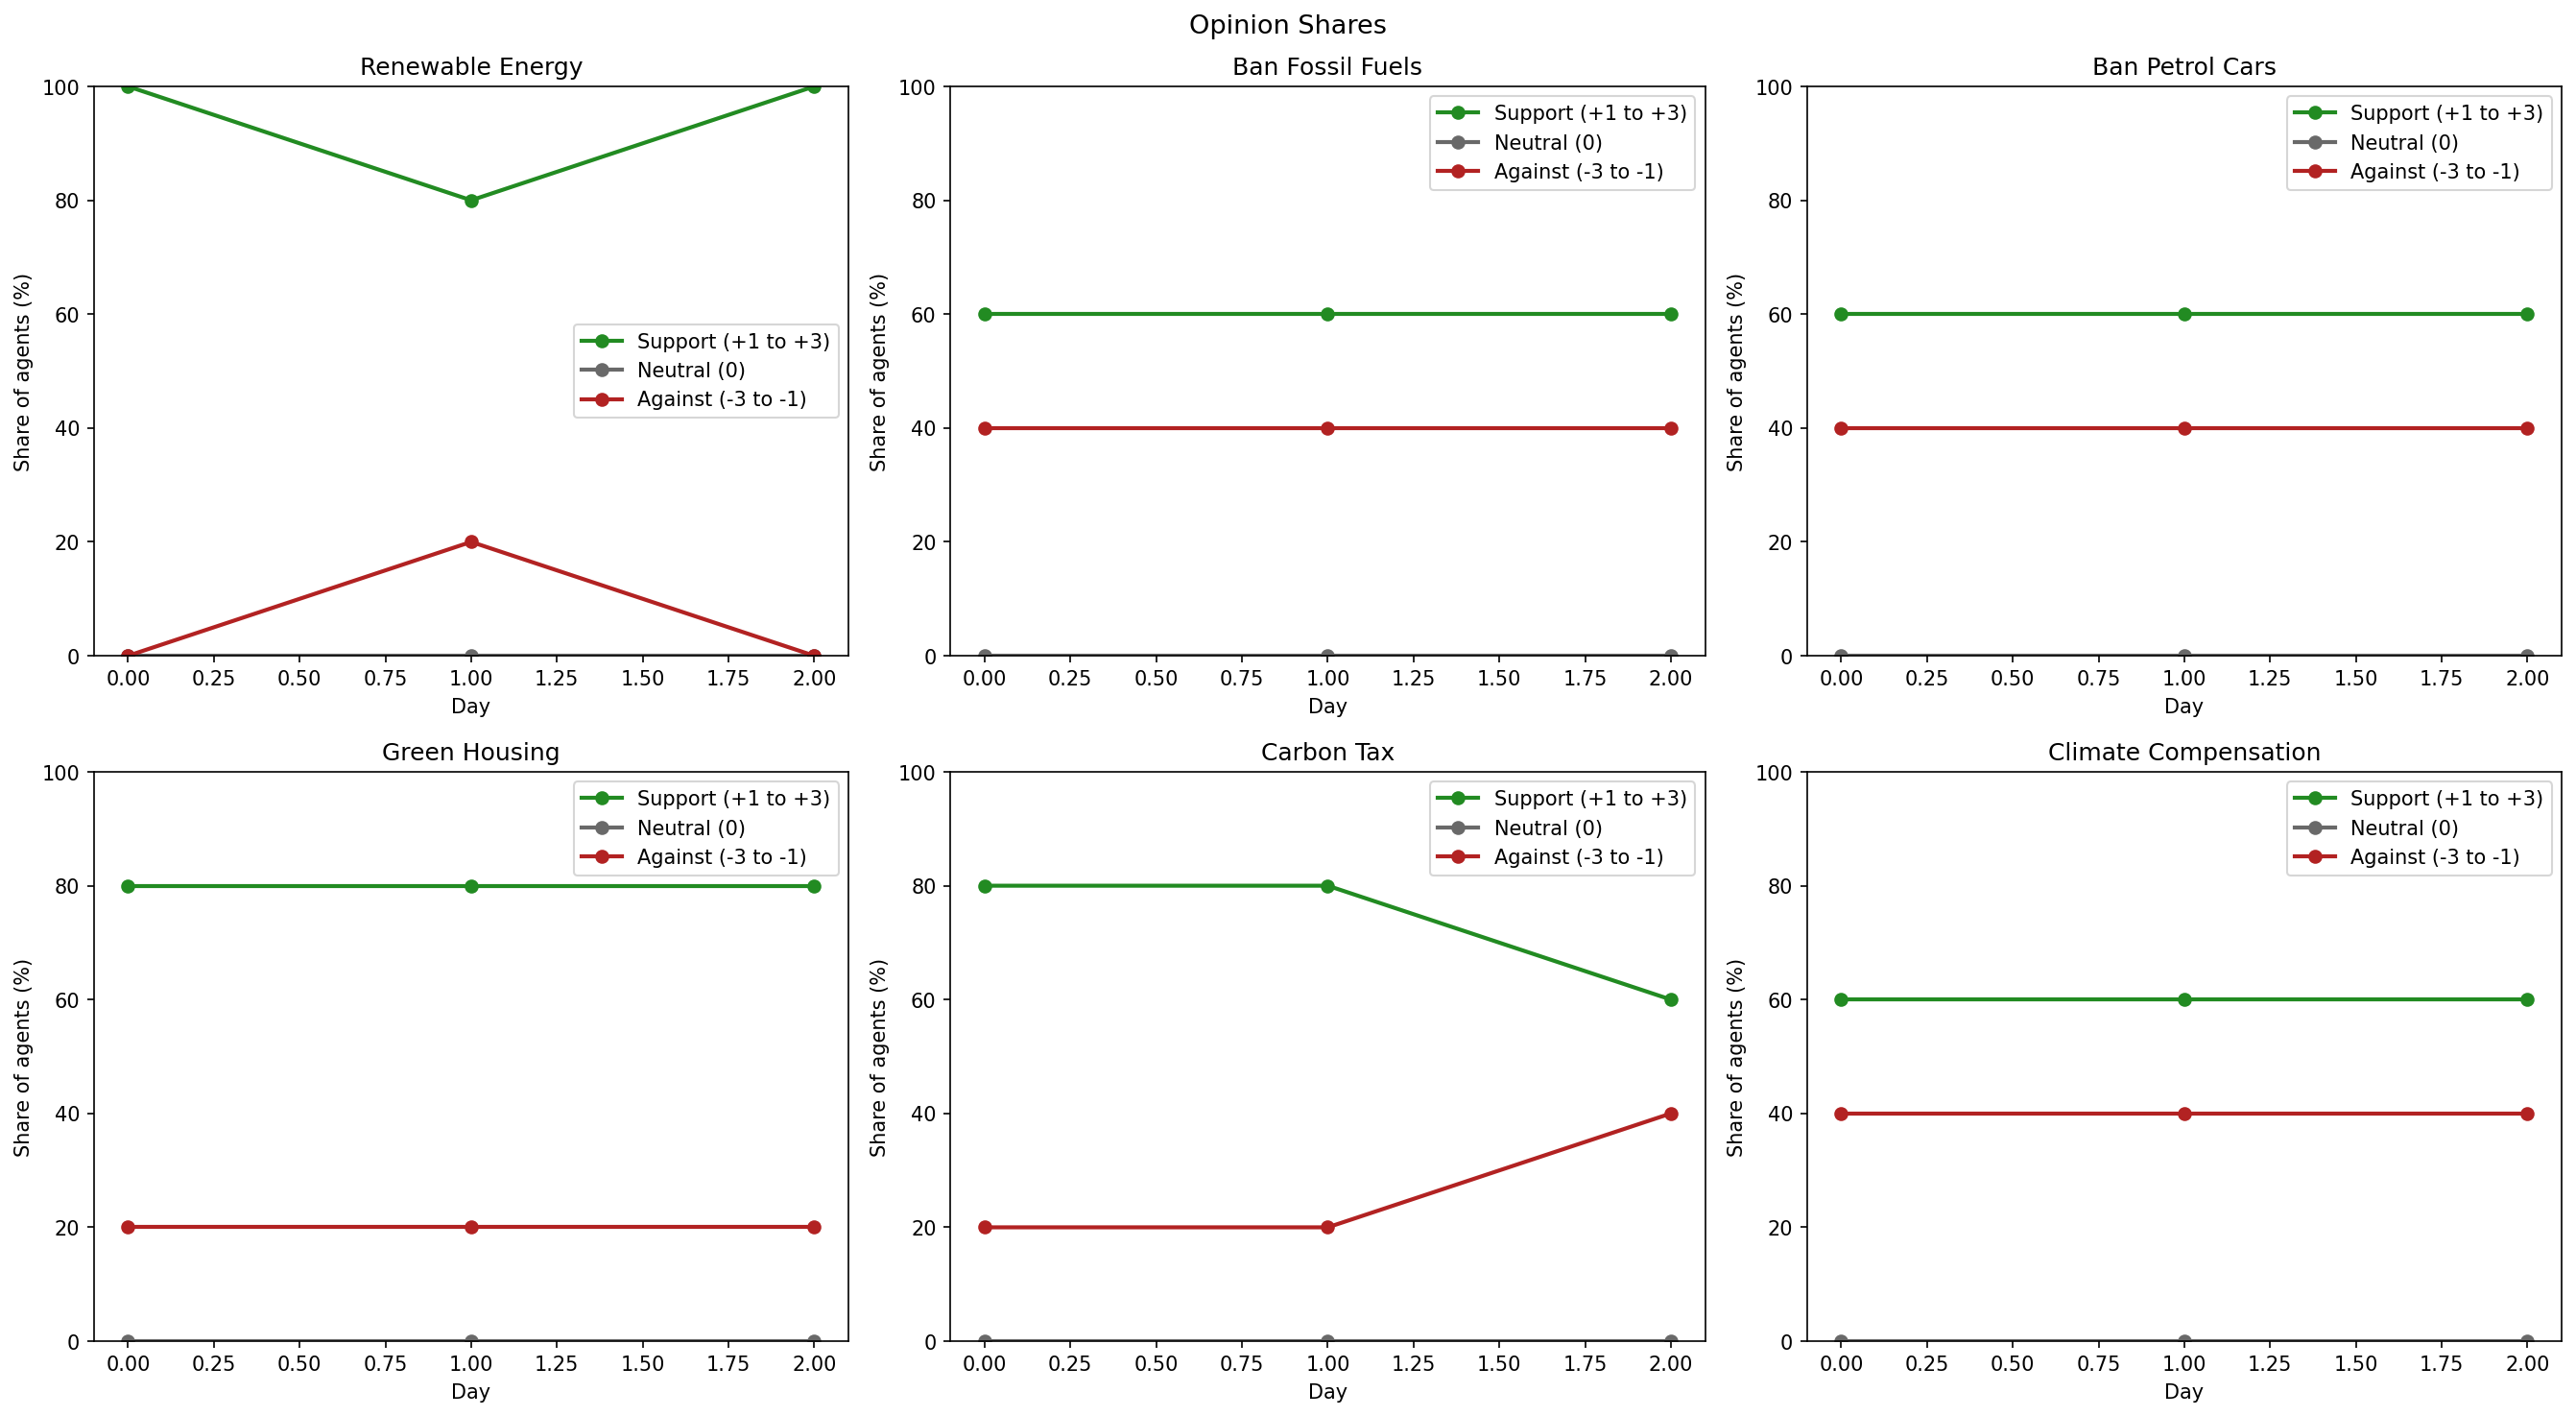

Inline preview: opinion_trajectories


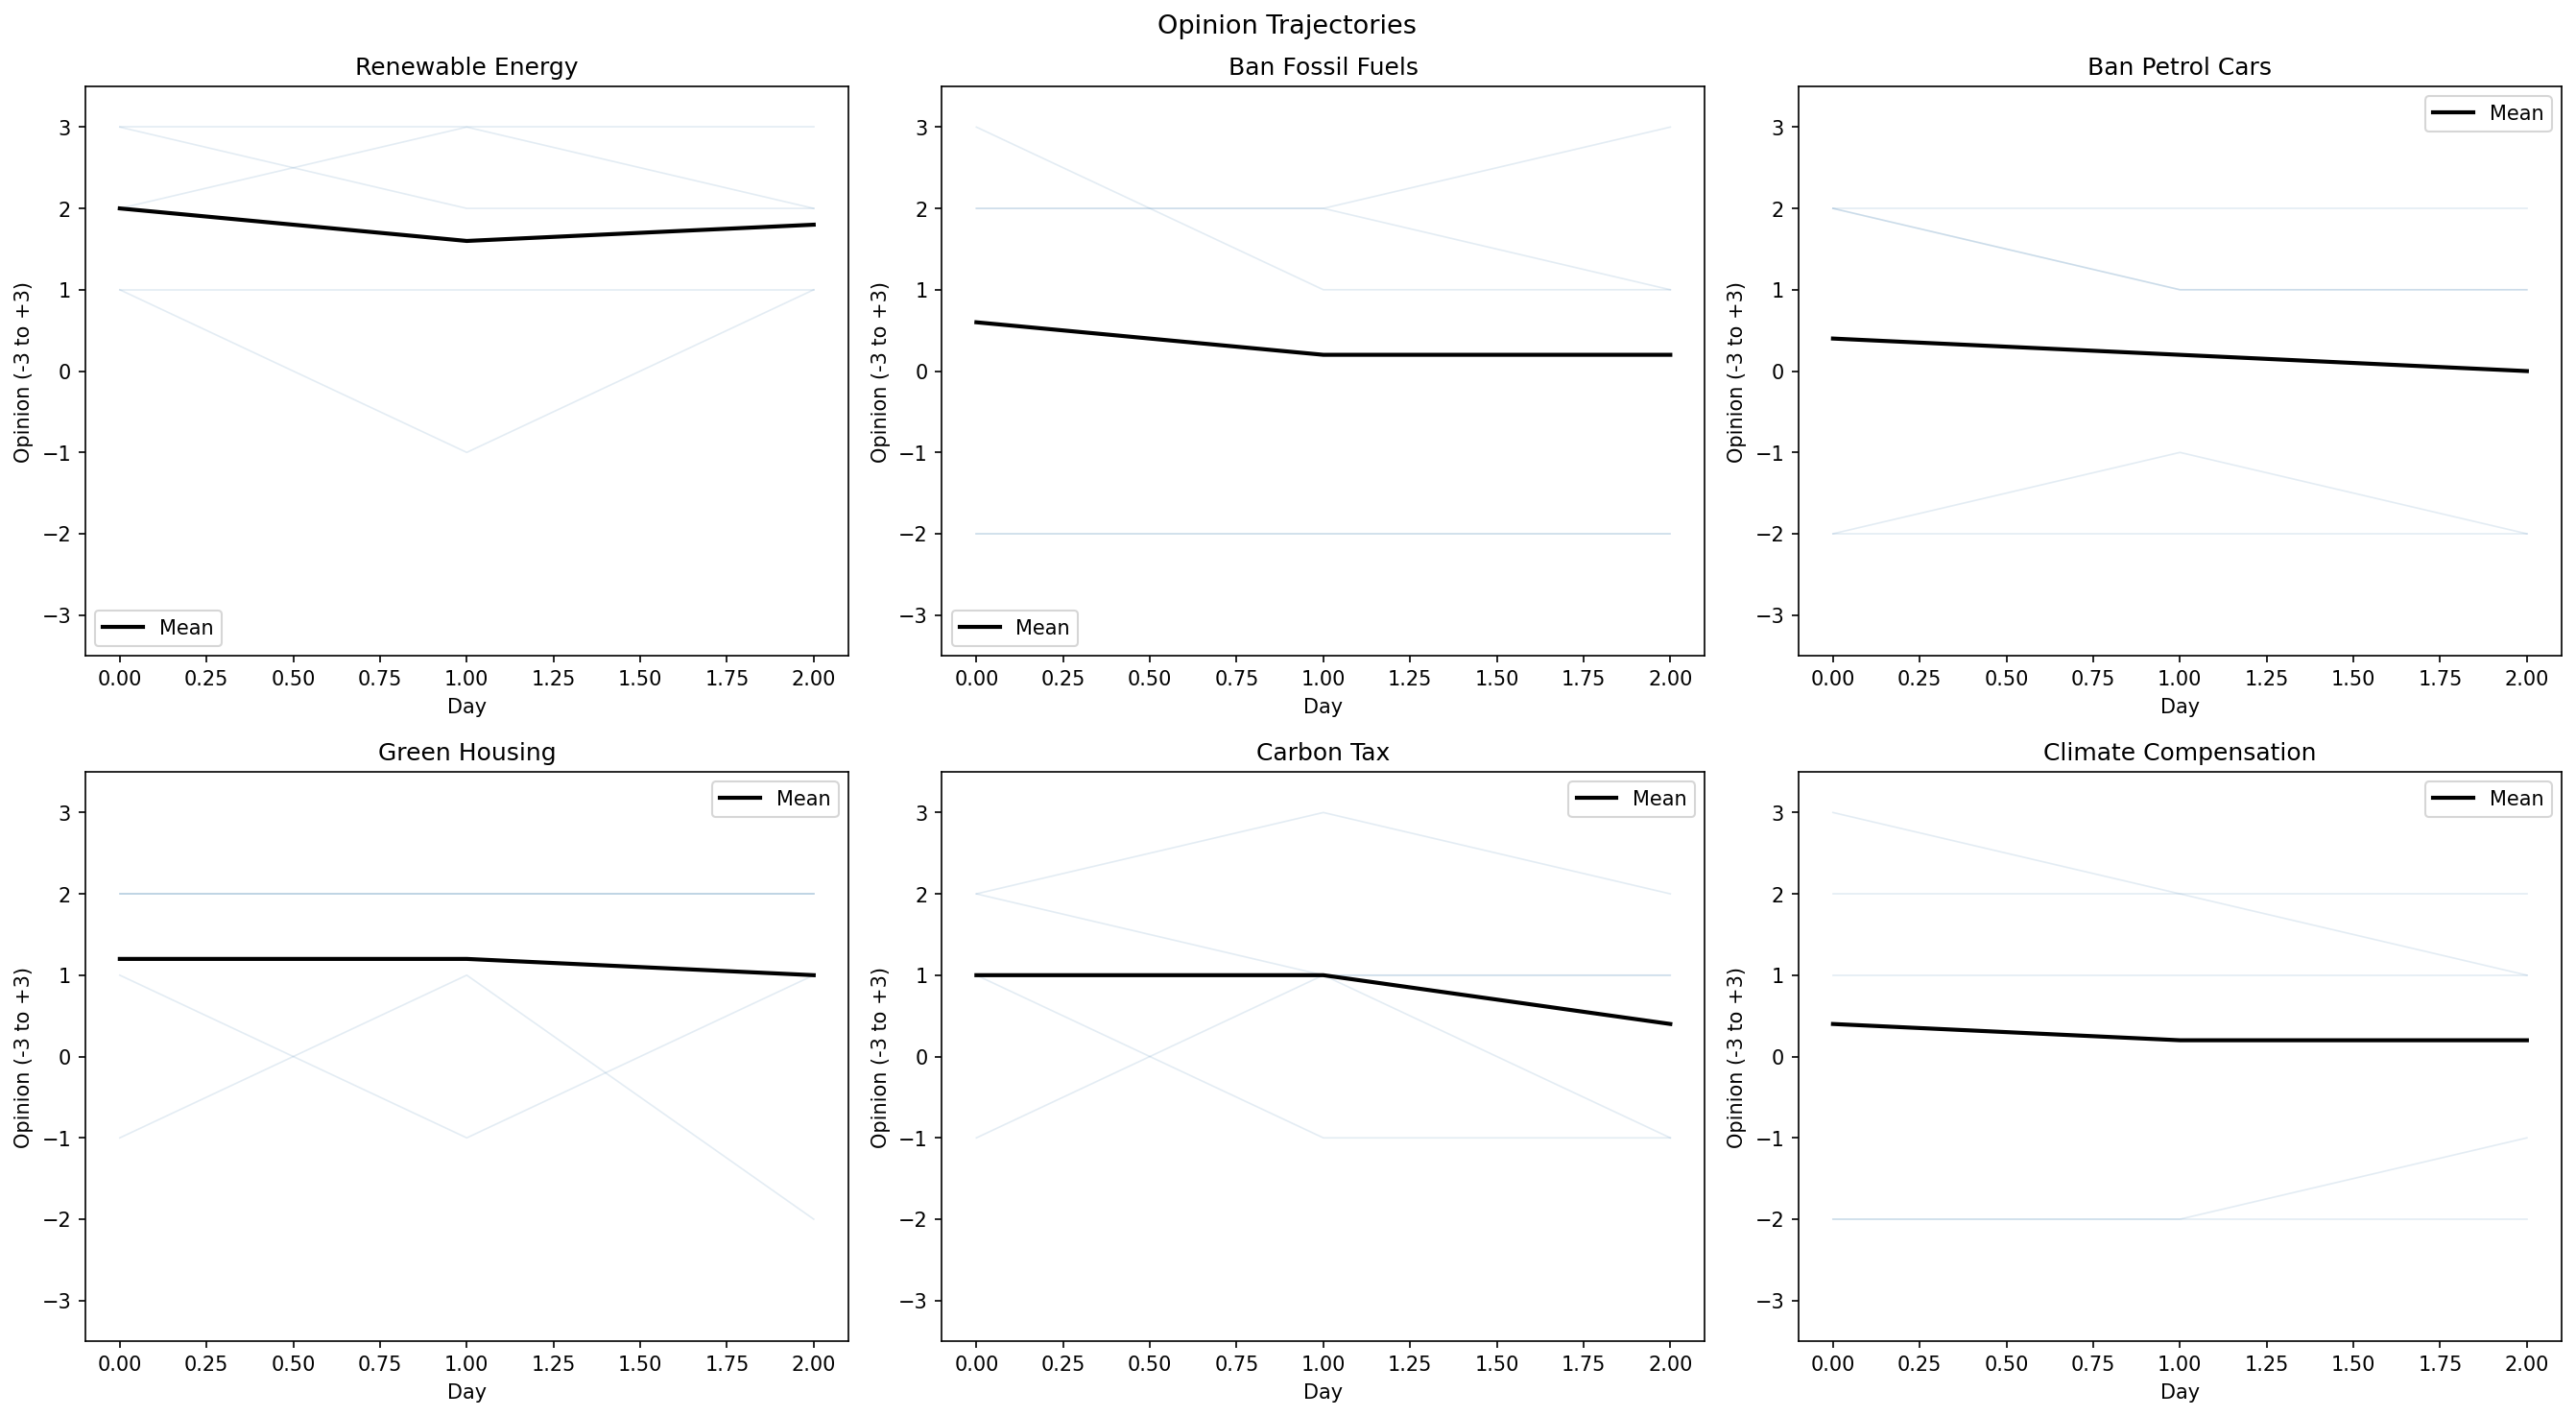

Inline preview: package_index_shares


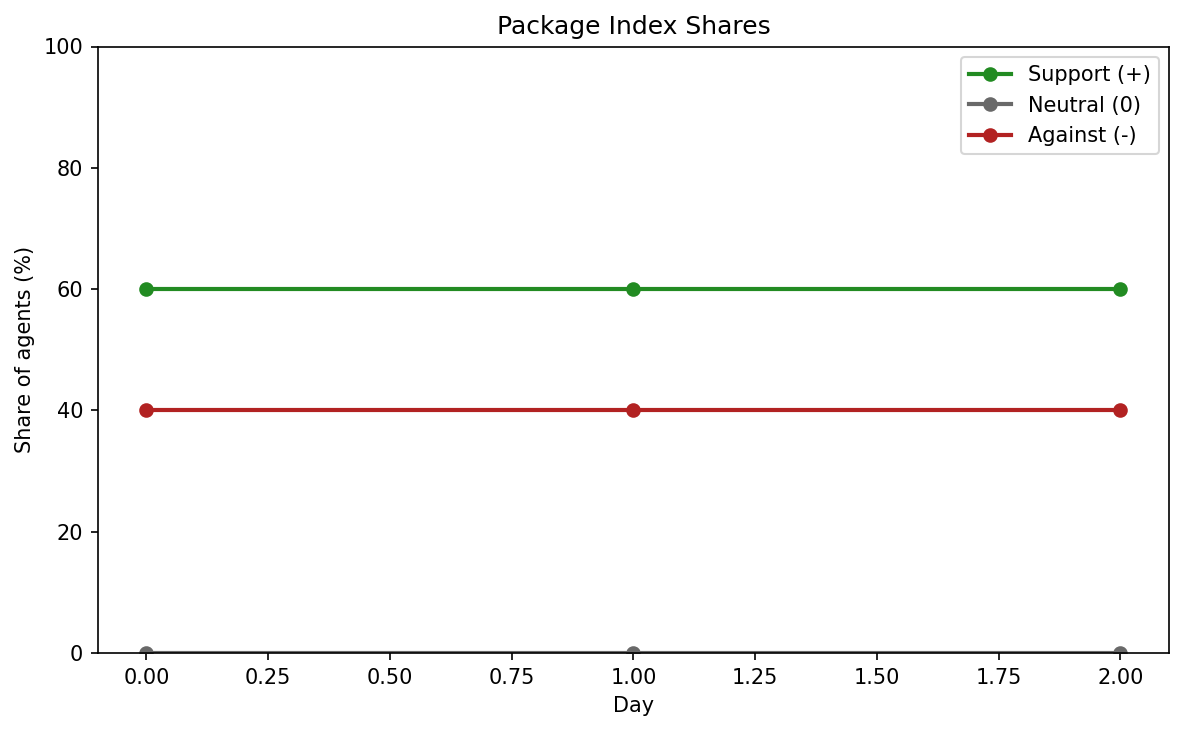

Inline preview: package_index_trajectories


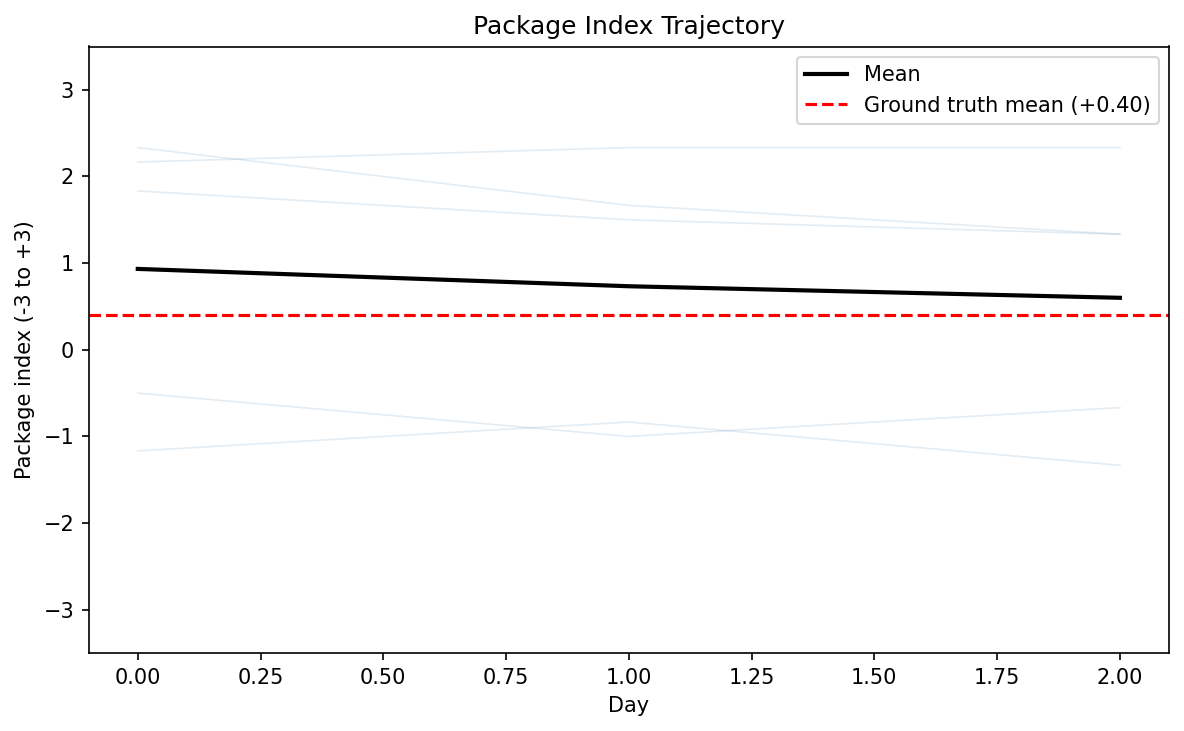

In [14]:
for plot_name, plot_path in sorted(live_plot_paths.items()):
    print(f'Inline preview: {plot_name}')
    display(Image(filename=str(plot_path)))

In [8]:
live_message_flow_summary = (
    live_messages_csv.groupby(
        ['message_type', 'phase', 'sender_type', 'recipient_scope'],
        dropna=False,
    )
    .size()
    .reset_index(name='n_rows')
    .sort_values(['message_type', 'phase', 'sender_type', 'recipient_scope'])
)

display(live_message_flow_summary)
display(
    live_messages_csv[
        [
            'day',
            'phase',
            'message_type',
            'sender_type',
            'sender_id',
            'recipient_id',
            'policy_id',
            'package_scope',
            'message_text',
        ]
    ].head(10)
)

,message_type,phase,sender_type,recipient_scope,n_rows
0,peer_message,C,citizen,direct,4
1,political_broadcast,P-A,political_agent,broadcast,10
2,political_broadcast,P-B,political_agent,broadcast,8


,day,phase,message_type,sender_type,sender_id,recipient_id,policy_id,package_scope,message_text
0,1,P-A,political_broadcast,political_agent,agent_a,1066.0,NaN,climate_policy_package,"In the face of the climate crisis, we have a p..."
1,1,P-A,political_broadcast,political_agent,agent_a,1260.0,NaN,climate_policy_package,"In the face of the climate crisis, we have a p..."
2,1,P-A,political_broadcast,political_agent,agent_a,1393.0,NaN,climate_policy_package,"In the face of the climate crisis, we have a p..."
3,1,P-A,political_broadcast,political_agent,agent_a,413.0,NaN,climate_policy_package,"In the face of the climate crisis, we have a p..."
4,1,P-A,political_broadcast,political_agent,agent_a,272.0,NaN,climate_policy_package,"In the face of the climate crisis, we have a p..."
5,1,P-B,political_broadcast,political_agent,agent_b,1260.0,NaN,climate_policy_package,Let’s be clear: the government’s climate polic...
6,1,P-B,political_broadcast,political_agent,agent_b,1393.0,NaN,climate_policy_package,Let’s be clear: the government’s climate polic...
7,1,P-B,political_broadcast,political_agent,agent_b,413.0,NaN,climate_policy_package,Let’s be clear: the government’s climate polic...
8,1,P-B,political_broadcast,political_agent,agent_b,272.0,NaN,climate_policy_package,Let’s be clear: the government’s climate polic...
9,1,C,peer_message,citizen,1066.0,413.0,NaN,climate_policy_package,I find myself strongly supportive of the clima...


In [9]:
if live_reasoning_csv.empty:
    print("survey_reasoning.csv is empty. Set live_config['debias'] = True if you want stored survey reasoning in the live run.")
else:
    display(live_reasoning_csv.head(10))

if live_summaries_csv.empty:
    print('daily_summaries.csv is empty. Increase LIVE_N_DAYS to at least 3 if you want stored daily memory summaries.')
else:
    display(live_summaries_csv.head(10))

,agent_id,day,policy_id,reasoning
0,1066.0,0,ClimatePolicyID(1),"Given this person's profile, they would likely..."
1,1066.0,1,ClimatePolicyID(1),"Given your demographic profile and values, you..."
2,1066.0,2,ClimatePolicyID(1),Given this person's demographic profile and va...
3,1066.0,0,ClimatePolicyID(2),"Given your demographic profile and values, you..."
4,1066.0,1,ClimatePolicyID(2),"Given your profile, you might support a ban on..."
5,1066.0,2,ClimatePolicyID(2),As a 37-year-old female with a left-wing polit...
6,1066.0,0,ClimatePolicyID(3),"Given your demographic profile and values, you..."
7,1066.0,1,ClimatePolicyID(3),Given this person's demographic profile and va...
8,1066.0,2,ClimatePolicyID(3),"Given your demographic profile and values, you..."
9,1066.0,0,ClimatePolicyID(4),Given this person's left-leaning political sta...


daily_summaries.csv is empty. Increase LIVE_N_DAYS to at least 3 if you want stored daily memory summaries.
